In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
df = pd.read_csv("bank_fraud.csv")

df.head()

,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000000001,CUST00121959,2023-08-17,21:13:00,21.0,0.0,0.0,USA,London,Grocery,...,39.49,157.0,23.0,52.7,10.20,0.0,0.0,0.0,0.0,NaN
1,TXN0000000002,CUST00146868,2024-02-06,05:16:00,5.0,0.0,1.0,UK,New York,Healthcare,...,153.71,153.0,23.0,0.9,12.47,0.0,0.0,0.0,0.0,NaN
2,TXN0000000003,CUST00131933,2024-06-28,12:15:00,12.0,0.0,0.0,Canada,Delhi,Grocery,...,118.20,161.0,20.0,9.2,0.08,0.0,1.0,0.0,0.0,NaN
3,TXN0000000004,CUST00103695,2023-03-16,02:53:00,2.0,0.0,1.0,France,Tokyo,Utilities,...,49.50,160.0,25.0,14.8,17.94,1.0,0.0,1.0,1.0,Synthetic Identity
4,TXN0000000005,CUST00119880,2024-07-12,12:39:00,12.0,0.0,0.0,Canada,Melbourne,Clothing,...,30.74,134.0,18.0,38.9,2.16,0.0,0.0,0.0,0.0,NaN


In [ ]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

(115874, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115874 entries, 0 to 115873
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   transaction_id            115874 non-null  object 
 1   customer_id               115873 non-null  object 
 2   transaction_date          115873 non-null  object 
 3   transaction_time          115873 non-null  object 
 4   hour_of_day               115873 non-null  float64
 5   is_weekend                115873 non-null  float64
 6   is_night_transaction      115873 non-null  float64
 7   country                   115873 non-null  object 
 8   city                      115873 non-null  object 
 9   merchant_category         115873 non-null  object 
 10  payment_method            115873 non-null  object 
 11  device_type               115873 non-null  object 
 12  customer_age              115873 non-null  float64
 13  credit_score              11587

In [ ]:
print(df['is_fraud'].value_counts())

print(df['is_fraud'].value_counts(normalize=True)*100)

is_fraud
0.0    109493
1.0      6380
Name: count, dtype: int64
is_fraud
0.0    94.493972
1.0     5.506028
Name: proportion, dtype: float64


In [ ]:
print(df.describe())

         hour_of_day     is_weekend  is_night_transaction   customer_age  \
count  115873.000000  115873.000000         115873.000000  115873.000000   
mean       11.495646       0.288229              0.374677      41.760281   
std         6.923620       0.452940              0.484042      13.421890   
min         0.000000       0.000000              0.000000      18.000000   
25%         5.000000       0.000000              0.000000      32.000000   
50%        11.000000       0.000000              0.000000      41.000000   
75%        18.000000       1.000000              1.000000      51.000000   
max        23.000000       1.000000              1.000000      85.000000   

        credit_score  account_age_years  account_balance  transaction_amount  \
count  115873.000000      115873.000000    115873.000000       115873.000000   
mean      679.123428           4.960860     16614.031620          205.613711   
std        78.918622           4.896049     28204.518664          481.89146

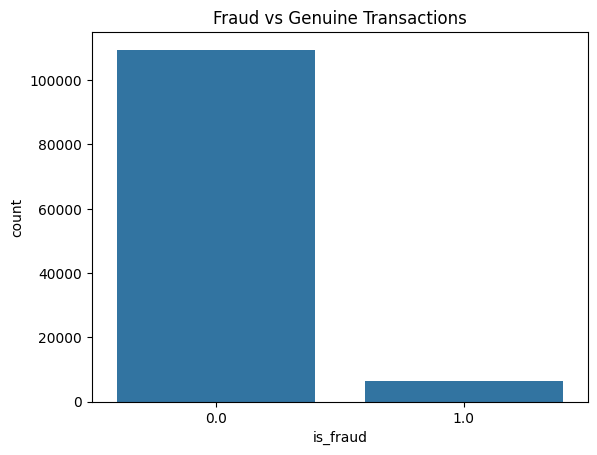

In [ ]:
sns.countplot(x='is_fraud', data=df)

plt.title("Fraud vs Genuine Transactions")

plt.show()

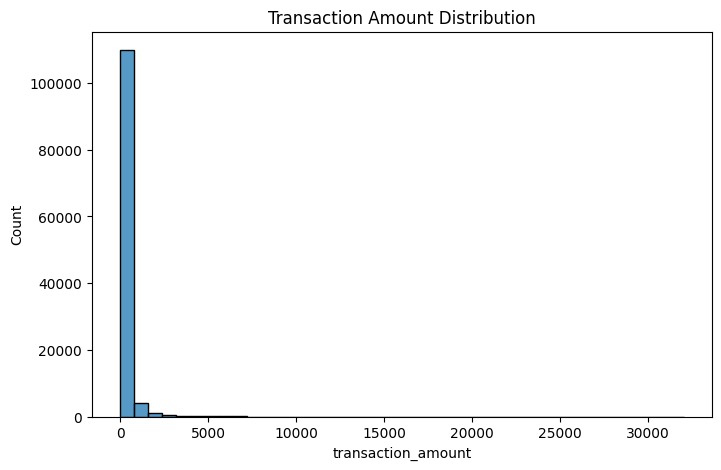

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['transaction_amount'], bins=40)

plt.title("Transaction Amount Distribution")

plt.show()

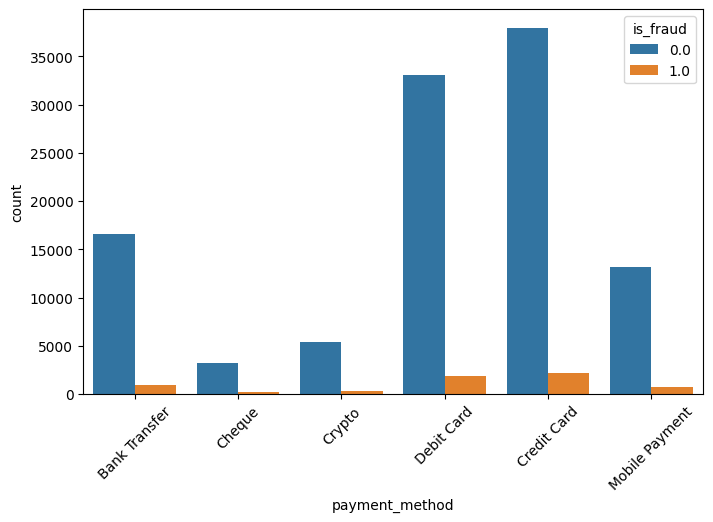

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='payment_method',
    hue='is_fraud',
    data=df
)

plt.xticks(rotation=45)

plt.show()

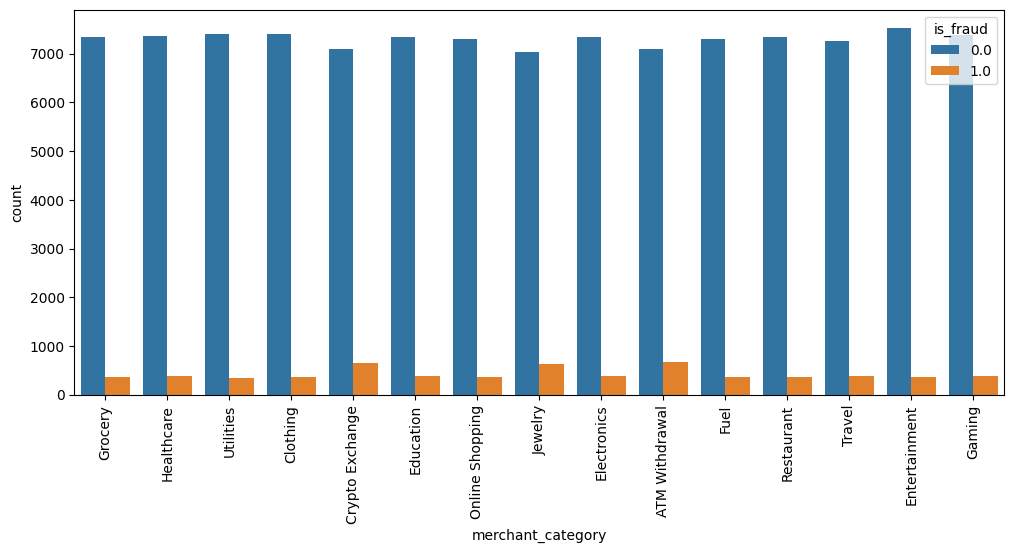

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='merchant_category',
    hue='is_fraud',
    data=df
)

plt.xticks(rotation=90)

plt.show()

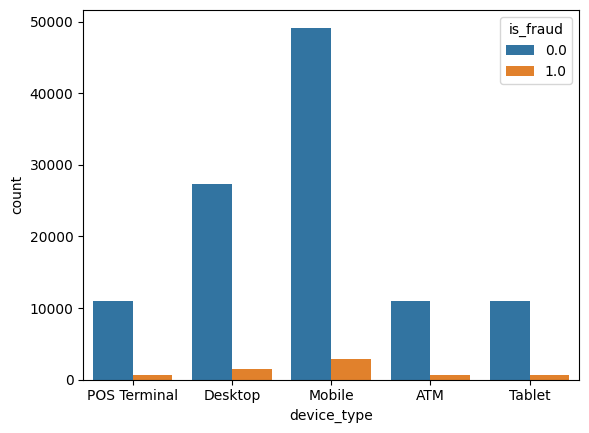

In [ ]:
sns.countplot(
    x='device_type',
    hue='is_fraud',
    data=df
)

plt.show()

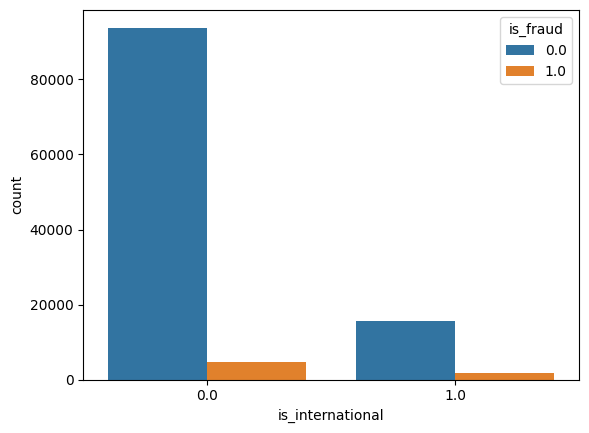

In [ ]:
sns.countplot(
    x='is_international',
    hue='is_fraud',
    data=df
)

plt.show()

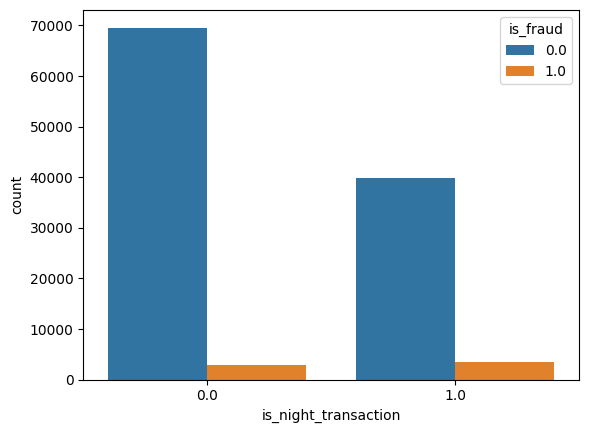

In [ ]:
sns.countplot(
    x='is_night_transaction',
    hue='is_fraud',
    data=df
)

plt.show()

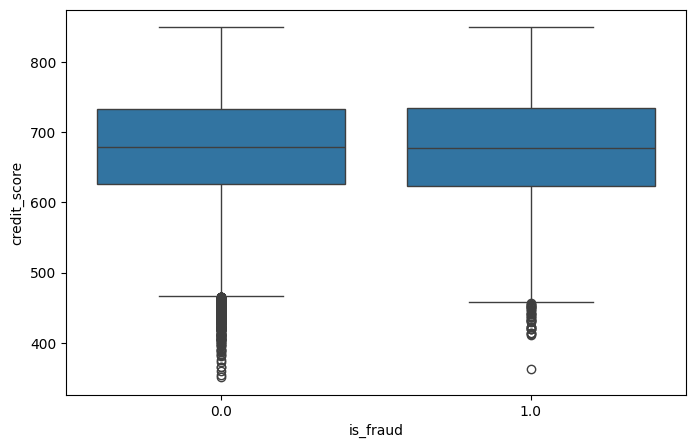

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_fraud',
    y='credit_score',
    data=df
)

plt.show()

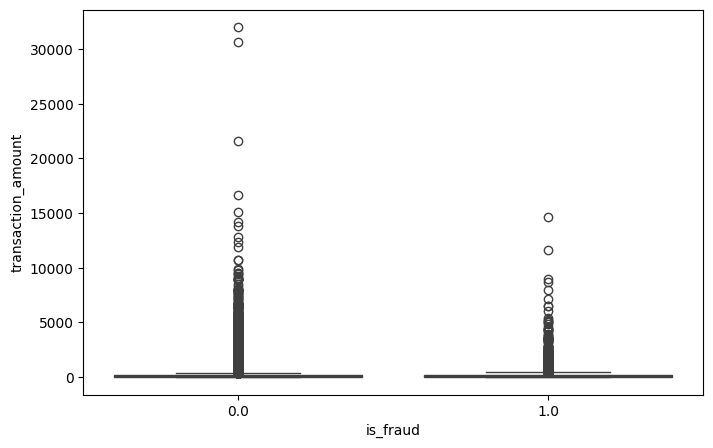

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_fraud',
    y='transaction_amount',
    data=df
)

plt.show()

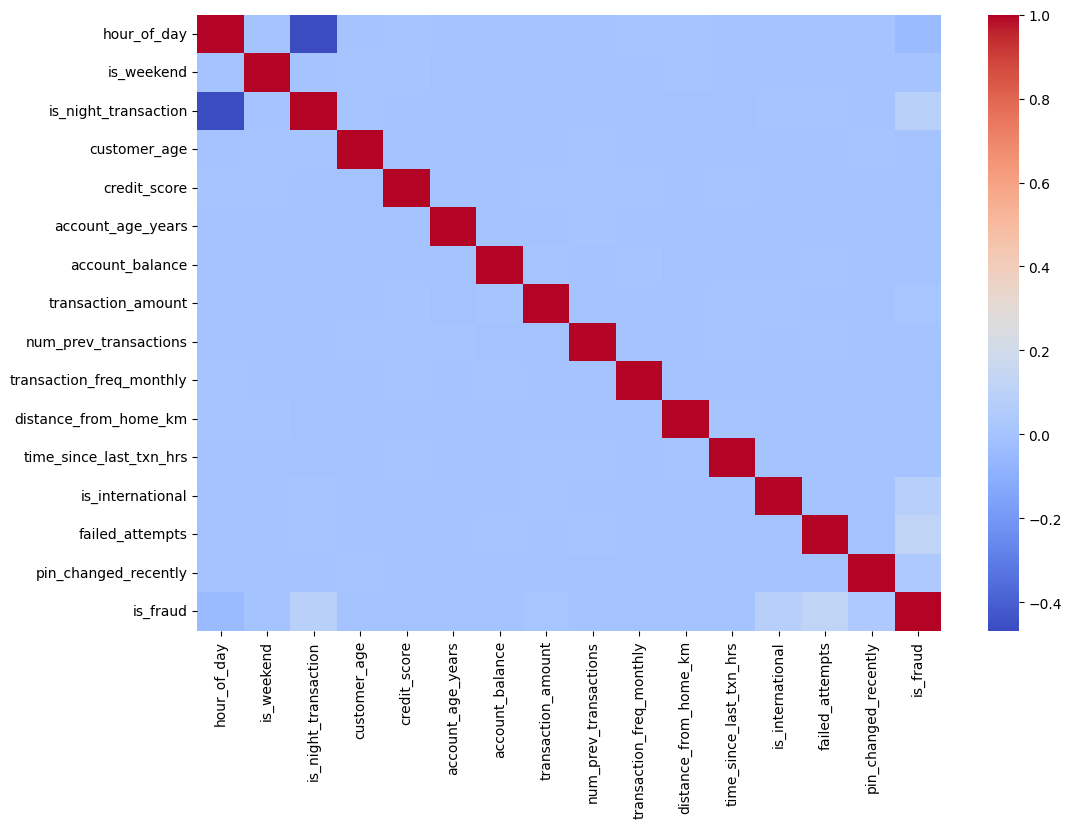

In [ ]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm'
)

plt.show()

In [ ]:
df = df.dropna(subset=['is_fraud'])

In [ ]:
X = df.drop(
    ['transaction_id',
     'customer_id',
     'transaction_date',
     'transaction_time',
     'fraud_type',
     'is_fraud'],
    axis=1
)

y = df['is_fraud']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
categorical_cols = X.select_dtypes(
    include='object'
).columns

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            Pipeline([
                ('imputer',
                 SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_cols
        )
    ],
    remainder='passthrough'
)

In [ ]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',
     RandomForestClassifier(
         n_estimators=100,
         random_state=42
     ))
])

In [ ]:
print(df['is_fraud'].isnull().sum())

0


In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['country', 'city', 'merchant_category', 'payment_method',
       'device_type'],
      dtype='object'))])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy:",
      accuracy_score(y_test, y_pred))

Accuracy: 0.9460194174757282


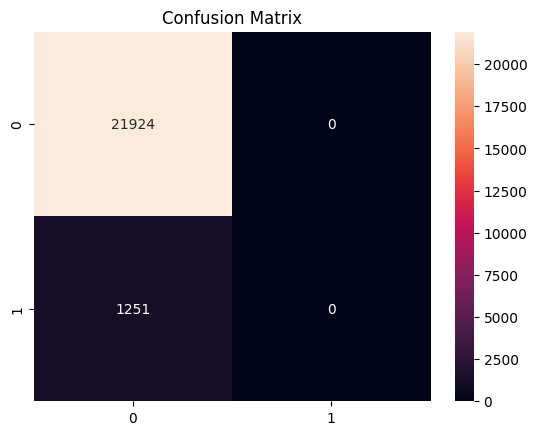

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97     21924
         1.0       0.00      0.00      0.00      1251

    accuracy                           0.95     23175
   macro avg       0.47      0.50      0.49     23175
weighted avg       0.89      0.95      0.92     23175



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
